## Deep Learning Model (Option C)

Define, train, and evaluate the deep learning classifier. Record training setup and report final metrics.


In [3]:
from pathlib import Path
import sys

# Add project root so src imports work when running from notebooks/.
sys.path.append(str(Path().resolve().parent))

from src.config import (
    PART1_KAGGLE_DIR,
    PART1_TRAIN_DIR,
    PART1_TEST_DIR,
)

# Validate Part 1 layout only (Part 2 is not needed for Option C)
assert PART1_TRAIN_DIR.exists(), f"Training data missing: {PART1_TRAIN_DIR}"
assert PART1_TEST_DIR.exists(), f"Test data missing: {PART1_TEST_DIR}"

print("Data paths validated:")
print(f"- Part 1 root : {PART1_KAGGLE_DIR}")
print(f"- Train       : {PART1_TRAIN_DIR}")
print(f"- Test        : {PART1_TEST_DIR}")

Data paths validated:
- Part 1 root : C:\Users\victo\Documents\ECSE 321\ecse415-final-project\data\part1\ecse-415-winter-2026-dog-vs-cat-classification
- Train       : C:\Users\victo\Documents\ECSE 321\ecse415-final-project\data\part1\ecse-415-winter-2026-dog-vs-cat-classification\train\train
- Test        : C:\Users\victo\Documents\ECSE 321\ecse415-final-project\data\part1\ecse-415-winter-2026-dog-vs-cat-classification\test\test


### Imports & Device Setup

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

from src.config import (
    IMG_SIZE_CNN,
    CLASS_NAMES,
    FIGURES_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
)
from src.utils import (
    load_labeled_images,
    split_data,
    get_pytorch_dataloaders,
    load_test_images,
    generate_submission_csv,
)
from src.evaluation import compute_metrics, compute_confusion_matrix
from src.visualization import (
    plot_confusion_matrix,
    plot_training_history,
    plot_sample_predictions,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Load and Split Data

Load all labeled images at 224×224 (the standard input size for ResNet), then create an 80/20 stratified train/val split and wrap them in PyTorch DataLoaders with ImageNet normalization.

> **Note:** Loading the full dataset into RAM can use ~15 GB.  
> Set `max_samples` below to limit per-class count if you run into memory issues (e.g., `max_samples=5000` ≈ 6 GB).

In [5]:
MAX_SAMPLES = 1000  # Set to None for full dataset; reduced here for quick validation

X, y = load_labeled_images(img_size=IMG_SIZE_CNN, grayscale=False, max_samples=MAX_SAMPLES)
print(f"Dataset: {X.shape}, labels: {y.shape}")
print(f"  Class 0 (cat): {(y == 0).sum()},  Class 1 (dog): {(y == 1).sum()}")

X_train, X_val, y_train, y_val = split_data(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

BATCH_SIZE = 32
train_loader, val_loader = get_pytorch_dataloaders(
    X_train, y_train, X_val, y_val, batch_size=BATCH_SIZE, img_size=IMG_SIZE_CNN
)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Loading dogs: 100%|██████████| 1000/1000 [00:18<00:00, 54.51it/s]


Dataset: (2000, 224, 224, 3), labels: (2000,)
  Class 0 (cat): 1000,  Class 1 (dog): 1000
Train: (1600, 224, 224, 3), Val: (400, 224, 224, 3)
Train batches: 50, Val batches: 13


### Model Definition

Fine-tune a pre-trained **ResNet-18** (ImageNet weights). Only the final fully-connected layer is replaced with a 2-class head. All backbone layers are frozen initially for faster convergence; they can be unfrozen later for full fine-tuning.

In [6]:
# Load pre-trained ResNet-18 and replace the classification head
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all backbone parameters
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer (unfrozen by default)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

# Training components
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print(f"Model: ResNet-18  |  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Final layer: Linear(in={num_features}, out=2)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\victo/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 42.2MB/s]


Model: ResNet-18  |  Trainable params: 1,026
Final layer: Linear(in=512, out=2)


### Training

**Phase 1 — Head only** (backbone frozen): Train the new FC layer for a few epochs with lr=1e-3.  
**Phase 2 — Full fine-tuning**: Unfreeze the entire network and continue training at a lower lr=1e-5.

The training loop tracks `train_loss`, `val_loss`, `train_acc`, and `val_acc` per epoch for plotting.

In [7]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="  Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Run evaluation. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="  Val  ", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


# ---- Phase 1: Train FC head only (backbone frozen) ----
NUM_EPOCHS_HEAD = 5
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_state = None

print(f"Phase 1: Training FC head only for {NUM_EPOCHS_HEAD} epochs")
for epoch in range(1, NUM_EPOCHS_HEAD + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"  Epoch {epoch}/{NUM_EPOCHS_HEAD} — "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# ---- Phase 2: Unfreeze backbone and fine-tune at lower LR ----
NUM_EPOCHS_FULL = 5

for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=1e-5)
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.1)

print(f"\nPhase 2: Full fine-tuning for {NUM_EPOCHS_FULL} epochs")
for epoch in range(1, NUM_EPOCHS_FULL + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler_ft.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"  Epoch {epoch}/{NUM_EPOCHS_FULL} — "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# Restore best weights
model.load_state_dict(best_state)
model = model.to(device)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Phase 1: Training FC head only for 5 epochs


  Epoch 1/5 — Train Loss: 0.4022, Train Acc: 0.8194, Val Loss: 0.1777, Val Acc: 0.9400


  Epoch 2/5 — Train Loss: 0.1637, Train Acc: 0.9506, Val Loss: 0.1266, Val Acc: 0.9525


  Epoch 3/5 — Train Loss: 0.1222, Train Acc: 0.9644, Val Loss: 0.1135, Val Acc: 0.9650


  Epoch 4/5 — Train Loss: 0.1258, Train Acc: 0.9569, Val Loss: 0.1064, Val Acc: 0.9550


...

  Epoch 1/5 — Train Loss: 0.0948, Train Acc: 0.9706, Val Loss: 0.0757, Val Acc: 0.9700


  Epoch 2/5 — Train Loss: 0.0576, Train Acc: 0.9838, Val Loss: 0.0666, Val Acc: 0.9750


  Epoch 3/5 — Train Loss: 0.0381, Train Acc: 0.9919, Val Loss: 0.0596, Val Acc: 0.9775


  Epoch 4/5 — Train Loss: 0.0164, Train Acc: 1.0000, Val Loss: 0.0602, Val Acc: 0.9775


  Epoch 5/5 — Train Loss: 0.0214, Train Acc: 0.9994, Val Loss: 0.0601, Val Acc: 0.9750

Best validation accuracy: 0.9775


### Training Curves

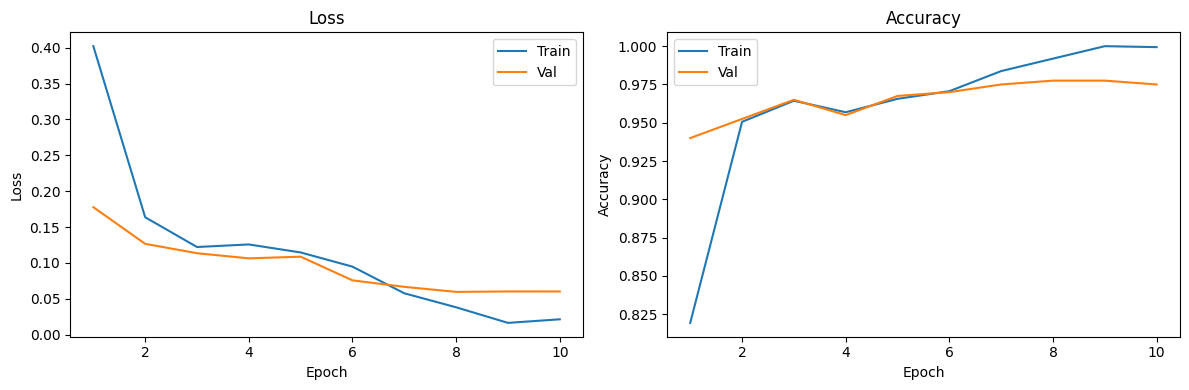

In [8]:
plot_training_history(history, save_path=FIGURES_DIR / "training_history_optionC.png")

### Evaluation on Internal Test Split

Run inference on the held-out validation set (Internal Test Split) and compute classification metrics + confusion matrix.

In [9]:
# Collect predictions on the validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Inference"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Compute metrics
metrics_c = compute_metrics(y_true, y_pred)
print("Option C (CNN — ResNet-18) Metrics:")
for k, v in metrics_c.items():
    print(f"  {k:>10s}: {v:.4f}")

# Confusion matrix
cm = compute_confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

Inference: 100%|██████████| 13/13 [00:03<00:00,  3.31it/s]


Option C (CNN — ResNet-18) Metrics:
    accuracy: 0.9775
   precision: 0.9897
      recall: 0.9650
          f1: 0.9772

Confusion Matrix:
[[198   2]
 [  7 193]]


### Confusion Matrix & Sample Predictions

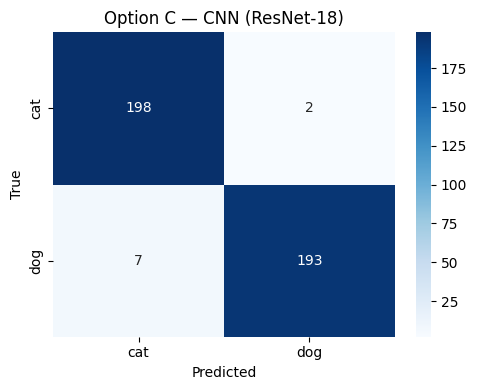

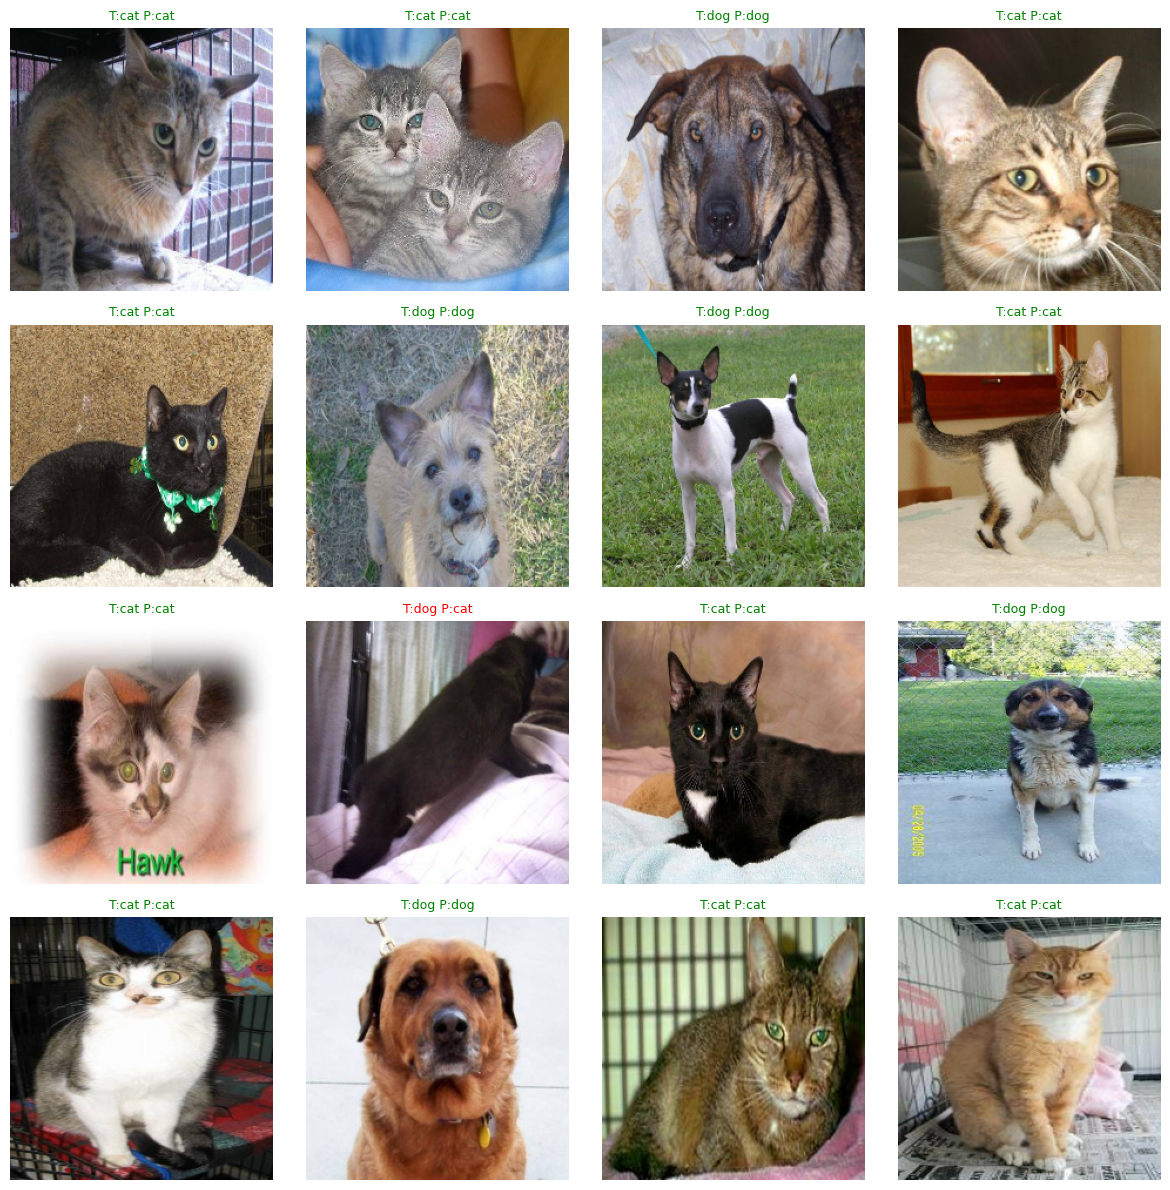

In [10]:
plot_confusion_matrix(
    cm,
    class_names=CLASS_NAMES,
    title="Option C — CNN (ResNet-18)",
    save_path=FIGURES_DIR / "confusion_matrix_optionC.png",
)

plot_sample_predictions(
    X_val,        # un-normalized numpy images for display
    y_true,
    y_pred,
    class_names=CLASS_NAMES,
    n=16,
    save_path=FIGURES_DIR / "sample_predictions_optionC.png",
)

### Save Model & Metrics

In [11]:
import json

# Save model weights
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "option_c_cnn.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# Save metrics as JSON for notebook 04 to load
metrics_path = MODELS_DIR / "metrics_optionC.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_c, f, indent=2)
print(f"Metrics saved to {metrics_path}")
print(metrics_c)

Model saved to C:\Users\victo\Documents\ECSE 321\ecse415-final-project\outputs\models\option_c_cnn.pth
Metrics saved to C:\Users\victo\Documents\ECSE 321\ecse415-final-project\outputs\models\metrics_optionC.json
{'accuracy': 0.9775, 'precision': 0.9897435897435898, 'recall': 0.965, 'f1': 0.9772151898734177}


### Kaggle Submission

Generate predictions on the unlabeled Kaggle Public Test Set and write a submission CSV. The label column contains the probability of the image being a dog (class 1).

In [12]:
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

# Load unlabeled test images
X_test, test_ids = load_test_images(img_size=IMG_SIZE_CNN, grayscale=False)
print(f"Test images: {X_test.shape}, IDs: {len(test_ids)}")

# Prepare test DataLoader with the same ImageNet normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
X_test_tensor = torch.from_numpy(X_test).permute(0, 3, 1, 2).float()
X_test_tensor = torch.stack([normalize(img) for img in X_test_tensor])
test_ds = TensorDataset(X_test_tensor)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Run inference — output dog probability (softmax column 1)
model.eval()
all_probs = []
with torch.no_grad():
    for (images,) in tqdm(test_loader, desc="Test inference"):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        all_probs.append(probs)

predictions = np.concatenate(all_probs)

# Write CSV
submission_path = generate_submission_csv(
    test_ids, predictions, OUTPUTS_DIR / "submission_optionC.csv"
)
print(f"Submission saved to {submission_path}  ({len(test_ids)} rows)")

Loading test images: 100%|██████████| 5000/5000 [00:07<00:00, 671.21it/s]


Test images: (5000, 224, 224, 3), IDs: 5000


Test inference: 100%|██████████| 157/157 [00:50<00:00,  3.13it/s]

Submission saved to C:\Users\victo\Documents\ECSE 321\ecse415-final-project\outputs\submission_optionC.csv  (5000 rows)
